In [249]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error,
                            accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, classification_report, silhouette_score)
from sklearn.decomposition import PCA


# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

For movies, popularity is determined by a variety of factors:

Number of votes for the day
Number of views for the day
Number of users who marked it as a "favourite" for the day
Number of users who added it to their "watchlist" for the day
Release date
Number of total votes
Previous days score

In [250]:
df = pd.read_csv('./data/TMDB_all_movies.csv')

In [251]:
df.shape

(1137484, 28)

In [252]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1137484.0,812971.597206,4.559456e+05,2.0,424302.7500,801807.0,1211651.500,1.595495e+06
vote_average,1137484.0,2.024402,3.062022e+00,0.0,0.0000,0.0,5.000,1.000000e+01
vote_count,1137484.0,22.734496,3.639583e+02,0.0,0.0000,0.0,1.000,3.834800e+04
revenue,1137484.0,713515.395995,1.697198e+07,-12.0,0.0000,0.0,0.000,2.923706e+09
runtime,1137484.0,44.393567,5.514778e+01,0.0,2.0000,22.0,85.000,1.440000e+04
budget,1137484.0,284644.195218,4.822096e+06,0.0,0.0000,0.0,0.000,9.000000e+08
popularity,1137484.0,0.888876,1.965798e+00,0.0,0.1437,0.6,1.028,5.301827e+02
imdb_rating,455301.0,6.264794,1.322991e+00,1.0,5.5000,6.4,7.200,1.000000e+01
imdb_votes,455301.0,2807.687209,3.221985e+04,5.0,20.0000,59.0,265.000,3.128869e+06


In [253]:
df.isnull().sum()

id                               0
title                           13
vote_average                     0
vote_count                       0
status                           0
release_date                117341
revenue                          0
runtime                          0
budget                           0
imdb_id                     494209
original_language                0
original_title                  12
overview                    174984
popularity                       0
tagline                     966509
genres                      309157
production_companies        593738
production_countries        426847
spoken_languages            418355
cast                        363797
director                    184685
director_of_photography     839325
writers                     565348
producers                   754082
music_composer             1013041
imdb_rating                 682183
imdb_votes                  682183
poster_path                 284353
dtype: int64

In [254]:
df.columns

Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'budget', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'cast', 'director', 'director_of_photography', 'writers', 'producers',
       'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path'],
      dtype='object')

In [255]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137484 entries, 0 to 1137483
Data columns (total 28 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id                       1137484 non-null  int64  
 1   title                    1137471 non-null  object 
 2   vote_average             1137484 non-null  float64
 3   vote_count               1137484 non-null  float64
 4   status                   1137484 non-null  object 
 5   release_date             1020143 non-null  object 
 6   revenue                  1137484 non-null  float64
 7   runtime                  1137484 non-null  float64
 8   budget                   1137484 non-null  float64
 9   imdb_id                  643275 non-null   object 
 10  original_language        1137484 non-null  object 
 11  original_title           1137472 non-null  object 
 12  overview                 962500 non-null   object 
 13  popularity               1137484 non-null 

| Column Name               | Description                                         | Dtype    | Non-Null Count |
|---------------------------|-----------------------------------------------------|----------|-----------------|
| id                        | Unique TMDB movie ID                                | int64    | 1,137,484       |
| title                     | Movie title (localized)                             | object   | 1,137,471       |
| vote_average              | TMDB average rating                                 | float64  | 1,137,484       |
| vote_count                | Number of TMDB votes                                | float64  | 1,137,484       |
| status                    | Release status                                      | object   | 1,137,484       |
| release_date              | Theatrical release date                             | object   | 1,020,143       |
| revenue                   | Box office revenue in USD                           | float64  | 1,137,484       |
| runtime                   | Duration in minutes                                 | float64  | 1,137,484       |
| budget                    | Production budget in USD                            | float64  | 1,137,484       |
| imdb_id                   | IMDb ID                                             | object   | 643,275         |
| original_language         | ISO-639-1 language code                              | object   | 1,137,484       |
| original_title            | Original film title                                 | object   | 1,137,472       |
| overview                  | Short synopsis / plot summary                       | object   | 962,500         |
| popularity                | TMDB popularity metric                              | float64  | 1,137,484       |
| tagline                   | Official movie tagline                              | object   | 170,975         |
| genres                    | List of movie genres                                | object   | 828,327         |
| production_companies      | Main production companies                           | object   | 543,746         |
| production_countries      | Countries where movie was produced                  | object   | 710,637         |
| spoken_languages          | Languages spoken in the movie                       | object   | 719,129         |
| cast                      | Full cast list                                      | object   | 773,687         |
| director                  | Movie director(s)                                   | object   | 952,799         |
| director_of_photography   | Cinematographer(s)                                  | object   | 298,159         |
| writers                   | Screenwriters / authors                             | object   | 572,136         |
| producers                 | Movie producers                                    | object   | 383,402         |
| music_composer            | Composer(s) of film score                           | object   | 124,443         |
| imdb_rating               | IMDb average rating                                 | float64  | 455,301         |
| imdb_votes                | IMDb number of votes                                | float64  | 455,301         |
| poster_path               | TMDB poster image path                              | object   | 853,131         |


## Data Preprocessing

In [256]:
# DATA PREPROCESSING - Filter out invalid/zero values
before_rows = df.shape[0]
print(f"Original dataset size: {df.shape[0]:,}")

# Filter out movies with unrealistic/zero values
df = df[df['budget'] >= 50000]        # Minimum budget $50K
df = df[df['revenue'] > 0]             # Must have revenue data
df = df[df['runtime'] >= 30]           # At least 30 minutes
df = df[df['vote_average'] > 0]        # Must have rating
df = df[df['vote_count'] >= 10]        # At least 10 votes for reliability
df = df[df['status'] == 'Released']    # Only released movies

# Parse release date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

# Drop rows with missing release year
df = df.dropna(subset=['release_year'])
df = df[df['release_year'] >= 1900]    # Valid year

print(f"After cleaning: {df.shape[0]:,} movies")
print(f"Removed: {before_rows - df.shape[0]:,} rows")

print("\n Cleaned data statistics:")
print(df[['budget', 'revenue', 'runtime', 'vote_average', 'release_year']].describe().T)

df.sample(5).T

Original dataset size: 1,137,484
After cleaning: 10,972 movies
Removed: 1,126,512 rows

 Cleaned data statistics:
                count          mean           std      min         25%  \
budget        10972.0  2.467074e+07  3.845543e+07  50000.0  3500000.00   
revenue       10972.0  6.694125e+07  1.562811e+08      1.0  2970120.75   
runtime       10972.0  1.098575e+02  2.222849e+01     31.0       95.00   
vote_average  10972.0  6.394197e+00  8.749159e-01      1.7        5.90   
release_year  10972.0  2.001598e+03  1.883871e+01   1915.0     1994.00   

                       50%         75%           max  
budget        1.100000e+07  28625000.0  5.839000e+08  
revenue       1.458912e+07  57534352.5  2.923706e+09  
runtime       1.050000e+02       120.0  4.220000e+02  
vote_average  6.446000e+00         7.0  9.000000e+00  
release_year  2.006000e+03      2015.0  2.025000e+03  
After cleaning: 10,972 movies
Removed: 1,126,512 rows

 Cleaned data statistics:
                count         

,511670,3864,766488,53904,9828
id,724665,7555,1092936,76788,16270
title,"Confess, Fletch",Rambo,The Holy Boy,Mankatha,Career Opportunities
vote_average,6.213,6.689,7.4,6.8,6.9
vote_count,355.0,4123.0,56.0,72.0,717.0
status,Released,Released,Released,Released,Released
release_date,2022-09-16 00:00:00,2008-01-24 00:00:00,2025-09-17 00:00:00,2011-08-31 00:00:00,1991-03-29 00:00:00
revenue,500000.0,113200000.0,377925.0,28000000.0,11336986.0
runtime,99.0,92.0,122.0,161.0,83.0
budget,20000000.0,50000000.0,4025000.0,6100000.0,6000000.0
imdb_id,tt12718300,tt0462499,tt33382323,tt1705772,tt0101545


In [257]:
from collections import defaultdict
import plotly.graph_objects as go

# Create a copy of the 'genres' column to avoid modifying the original dataset
genres_copy = df['genres'].fillna('').str.split(',')

# Function to process genres and create hierarchical structure with movie titles
def process_genres(genres_series, titles_series):
    genre_hierarchy = defaultdict(lambda: defaultdict(list))
    for genres, title in zip(genres_series, titles_series):
        # Skip if title is NaN or not a string
        if pd.isna(title) or not isinstance(title, str):
            continue
        genres = [g.strip() for g in genres if g.strip()]
        if genres:
            main_genre = genres[0]
            genre_hierarchy[main_genre][''].append(title)
            if len(genres) > 1:
                subgenre = genres[1]
                genre_hierarchy[main_genre][subgenre].append(title)
    
    # Sort movie titles alphabetically for each genre and subgenre
    for main_genre in genre_hierarchy:
        for subgenre in genre_hierarchy[main_genre]:
            # Filter out any remaining non-string values before sorting
            genre_hierarchy[main_genre][subgenre] = sorted(
                [t for t in genre_hierarchy[main_genre][subgenre] if isinstance(t, str)]
            )
    
    return genre_hierarchy

# Process genres
genre_data = process_genres(genres_copy, df['title'])

# Prepare data for sunburst chart
labels = []
parents = []
values = []
colors = []
hover_text = []
color_map = {
    'Drama': '#1f77b4', 'Comedy': '#ff7f0e', 'Horror': '#2ca02c', 
    'Thriller': '#d62728', 'Documentary': '#9467bd', 'Action': '#8c564b',
    'Romance': '#e377c2', 'Science Fiction': '#7f7f7f', 'Fantasy': '#bcbd22',
    'Adventure': '#17becf', 'Animation': '#ffa500', 'Crime': '#800080',
    'War': '#008080', 'History': '#ff1493'
}
for main_genre, subgenres in genre_data.items():
    main_genre_count = len(subgenres[''])
    labels.append(main_genre)
    parents.append('')
    values.append(main_genre_count)
    colors.append(color_map.get(main_genre, '#636363'))
    # Limit hover text to first 20 movies to avoid huge tooltips
    hover_text.append("<br>".join(subgenres[''][:20]) + ("..." if len(subgenres['']) > 20 else ""))
    
    for subgenre, movies in subgenres.items():
        if subgenre:
            labels.append(f"{main_genre}-{subgenre}")
            parents.append(main_genre)
            values.append(len(movies))
            colors.append(color_map.get(main_genre, '#636363'))
            hover_text.append("<br>".join(movies[:20]) + ("..." if len(movies) > 20 else ""))

# Create sunburst chart
fig = go.Figure(go.Sunburst(
    labels=labels,
    parents=parents,
    values=values,
    branchvalues="total",
    marker=dict(colors=colors),
    hovertemplate='<b>%{label}</b><br><b>Movies:</b> %{value}<br><b>Percentage:</b> %{percentEntry:.0%}<br><b>Titles:</b><br>%{customdata}',
    customdata=hover_text,
    name=''
))

fig.update_layout(
    title="Movies Genre Distribution",
    width=800,
    height=800,
)

fig.show()

In [ ]:
from IPython.display import display, HTML

# TMDB poster base URL
POSTER_BASE_URL = "https://image.tmdb.org/t/p/w500"

# Flexible function to show posters with additional info
def show_posters_with_info(df, column_name, nb_of_movies, output_file='top_movies.html', min_budget=1000000):
    # Drop rows where the specified column or poster_path is NaN
    df_filtered = df.dropna(subset=[column_name, 'poster_path'])
    
    # Filter by minimum budget to exclude micro-budget films with unrealistic ROI
    if min_budget > 0:
        df_filtered = df_filtered[df_filtered['budget'] >= min_budget]

    # Sort by the specified column and get the top n movies
    top_movies = df_filtered.sort_values(by=column_name, ascending=False).head(nb_of_movies)
    
    html = "<div style='display: flex; flex-wrap: wrap;'>"
    movie_count = 0
    
    for index, row in top_movies.iterrows():
        title = row['title']
        poster_path = row['poster_path']
        budget = row['budget']
        revenue = row['revenue']
        column_value = row[column_name]
        
        # Format budget and revenue properly
        if budget >= 1000000:
            budget_str = f"${budget / 1000000:.1f}M"
        else:
            budget_str = f"${budget / 1000:.0f}K"
            
        if revenue >= 1000000:
            revenue_str = f"${revenue / 1000000:.1f}M"
        else:
            revenue_str = f"${revenue / 1000:.0f}K"
        
        # Format the column value based on the column name
        if column_name == 'ROI':
            column_value = f"{int(column_value):,}%"
        elif column_name == 'profit':
            column_value = f"${int(column_value // 1000000)}M"
        elif column_name == 'vote_average':
            column_value = f"{column_value:.1f}"
        
        if pd.notnull(poster_path):
            movie_count += 1
            full_poster_url = f"{POSTER_BASE_URL}{poster_path}"
            html += f"""
            <div style="margin: 10px; width: 200px; position: relative;">
                <img src="{full_poster_url}" alt="{title}" style="width: 100%; border-radius: 8px;">
                <div style="text-align: center; position: absolute; bottom: 0; width: 100%; background-color: rgba(0, 0, 0, 0.7); color: white; font-size: 12px; padding: 5px; border-radius: 0 0 8px 8px;">
                    <strong>{title}</strong><br>
                    Budget: {budget_str}<br>
                    Revenue: {revenue_str}<br>
                    {column_name.upper()}: {column_value}
                </div>
            </div>
            """
            
        # Break the loop if we have reached the desired number of movies with valid posters
        if movie_count == nb_of_movies:
            break
    
    html += "</div>"
    
    with open(output_file, 'w', encoding='utf-8') as file:
        file.write(html)
    
    display(HTML(html))

In [259]:
# Calculate ROI (Return on Investment) for movies with valid budget and revenue
df['ROI'] = ((df['revenue'] - df['budget']) / df['budget']) * 100

# Calculate Profit
df['profit'] = df['revenue'] - df['budget']

show_posters_with_info(df, 'ROI', 20, 'top_roi_movies.html', min_budget=1000000)

In [260]:
show_posters_with_info(df, 'vote_average', 20, 'top_rated_movies.html', min_budget=1000000)

In [261]:
show_posters_with_info(df, 'profit', 20, 'top_profit_movies.html', min_budget=1000000)

In [262]:
# Budget vs Revenue scatter plot with profitability coloring
fig = px.scatter(df, x='budget', y='revenue', color='profit',
                 hover_data=['title', 'vote_average', 'ROI'],
                 title='Budget vs Revenue (Colored by Profit)',
                 labels={'budget': 'Budget ($)', 'revenue': 'Revenue ($)', 'profit': 'Profit ($)'},
                 color_continuous_scale='RdYlGn')
fig.add_shape(type='line', x0=0, y0=0, x1=df['budget'].max(), y1=df['budget'].max(),
              line=dict(color='red', dash='dash'), name='Break-even line')
fig.update_layout(height=600, width=1000)
fig.show()

# Movie Success Prediction Model

## Business Problem
**Predict movie success based on pre-production features** to help investors and studios identify potentially successful projects before committing resources.

### Features Used:
- **Budget** - Production budget (adjusted for era)
- **Cast** - Star power and experience
- **Director** - Track record and reputation
- **Music Composer** - Quality of score
- **Writers** - Script quality indicators
- **Producers** - Production experience
- **Director of Photography** - Visual quality
- **Genres** - Genre popularity and trends
- **Tagline** - Marketing appeal
- **Overview** - Story quality indicators
- **Runtime** - Optimal length for genre
- **Release Date** - Seasonal timing and competition

### Success Definition:
A movie is considered **successful** if:
1. ROI (Return on Investment) > 150% (doubled the investment)
2. OR vote_average >= 6.5 (critically acclaimed)

In [263]:
# Data Cleaning for Success Prediction Model

# Create a copy of data for success prediction model
df_success = df.copy()

required_cols = ['budget', 'runtime', 'genres', 'release_year', 'revenue', 'vote_average',
                 'cast', 'director', 'music_composer', 'writers', 'producers', 
                 'director_of_photography', 'tagline', 'overview']

# Check missing values for required columns
missing_before = df_success[required_cols].isnull().sum()
missing_pct = (missing_before / len(df_success)) * 100
missing_info = pd.DataFrame({
    'Missing_Count': missing_before,
    'Percentage': missing_pct.round(2)
}).sort_values('Percentage', ascending=False)
print(missing_info)
print(f"\nTotal rows before cleaning: {len(df_success):,}")

                         Missing_Count  Percentage
tagline                           1693       15.43
music_composer                    1686       15.37
director_of_photography            801        7.30
producers                          328        2.99
writers                             58        0.53
genres                               3        0.03
cast                                 3        0.03
overview                             1        0.01
vote_average                         0        0.00
runtime                              0        0.00
budget                               0        0.00
revenue                              0        0.00
release_year                         0        0.00
director                             0        0.00

Total rows before cleaning: 10,972


In [264]:
# DROP NA VALUES

# Drop rows with missing values in critical numeric columns
critical_cols = ['budget', 'runtime', 'revenue', 'vote_average', 'release_year']
df_success = df_success.dropna(subset=critical_cols)

# For text columns, fill NA with empty string (will be handled in feature engineering)
text_cols = ['cast', 'director', 'music_composer', 'writers', 'producers', 
             'director_of_photography', 'tagline', 'overview', 'genres']
for col in text_cols:
    df_success[col] = df_success[col].fillna('')

print(f"Rows after dropping NA in critical columns: {len(df_success):,}")
print(f"Rows dropped: {len(df) - len(df_success):,}")

Rows after dropping NA in critical columns: 10,972
Rows dropped: 0


In [265]:
# IDENTIFY AND DROP DUPLICATES

# Check for duplicates based on title and release_year
duplicates_count = df_success.duplicated(subset=['title', 'release_year']).sum()
print(f"Duplicate movies (same title + year): {duplicates_count:,}")

# Drop duplicates, keeping the first occurrence
df_success = df_success.drop_duplicates(subset=['title', 'release_year'], keep='first')
print(f"Rows after removing duplicates: {len(df_success):,}")

Duplicate movies (same title + year): 0
Rows after removing duplicates: 10,972


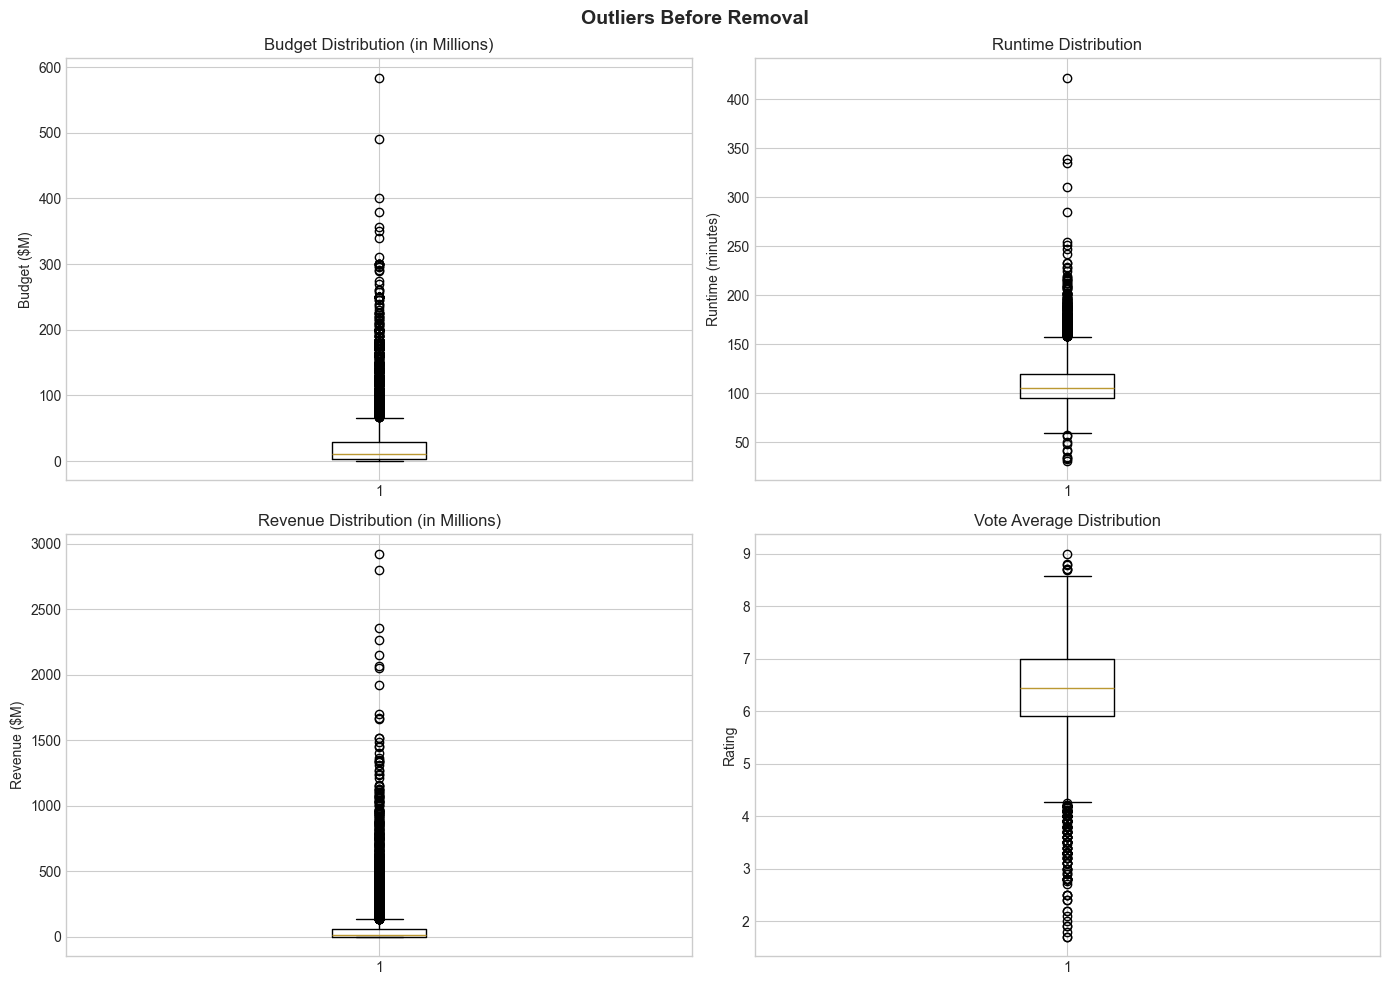


Rows before outlier removal: 10,972


In [266]:
# IDENTIFY AND DROP OUTLIERS (IQR Method)

# Visualize outliers before removal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Budget outliers
axes[0, 0].boxplot(df_success['budget'] / 1e6)
axes[0, 0].set_title('Budget Distribution (in Millions)')
axes[0, 0].set_ylabel('Budget ($M)')

# Runtime outliers
axes[0, 1].boxplot(df_success['runtime'])
axes[0, 1].set_title('Runtime Distribution')
axes[0, 1].set_ylabel('Runtime (minutes)')

# Revenue outliers
axes[1, 0].boxplot(df_success['revenue'] / 1e6)
axes[1, 0].set_title('Revenue Distribution (in Millions)')
axes[1, 0].set_ylabel('Revenue ($M)')

# Vote average
axes[1, 1].boxplot(df_success['vote_average'])
axes[1, 1].set_title('Vote Average Distribution')
axes[1, 1].set_ylabel('Rating')

plt.suptitle('Outliers Before Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRows before outlier removal: {len(df_success):,}")

Rows after outlier removal: 10,270


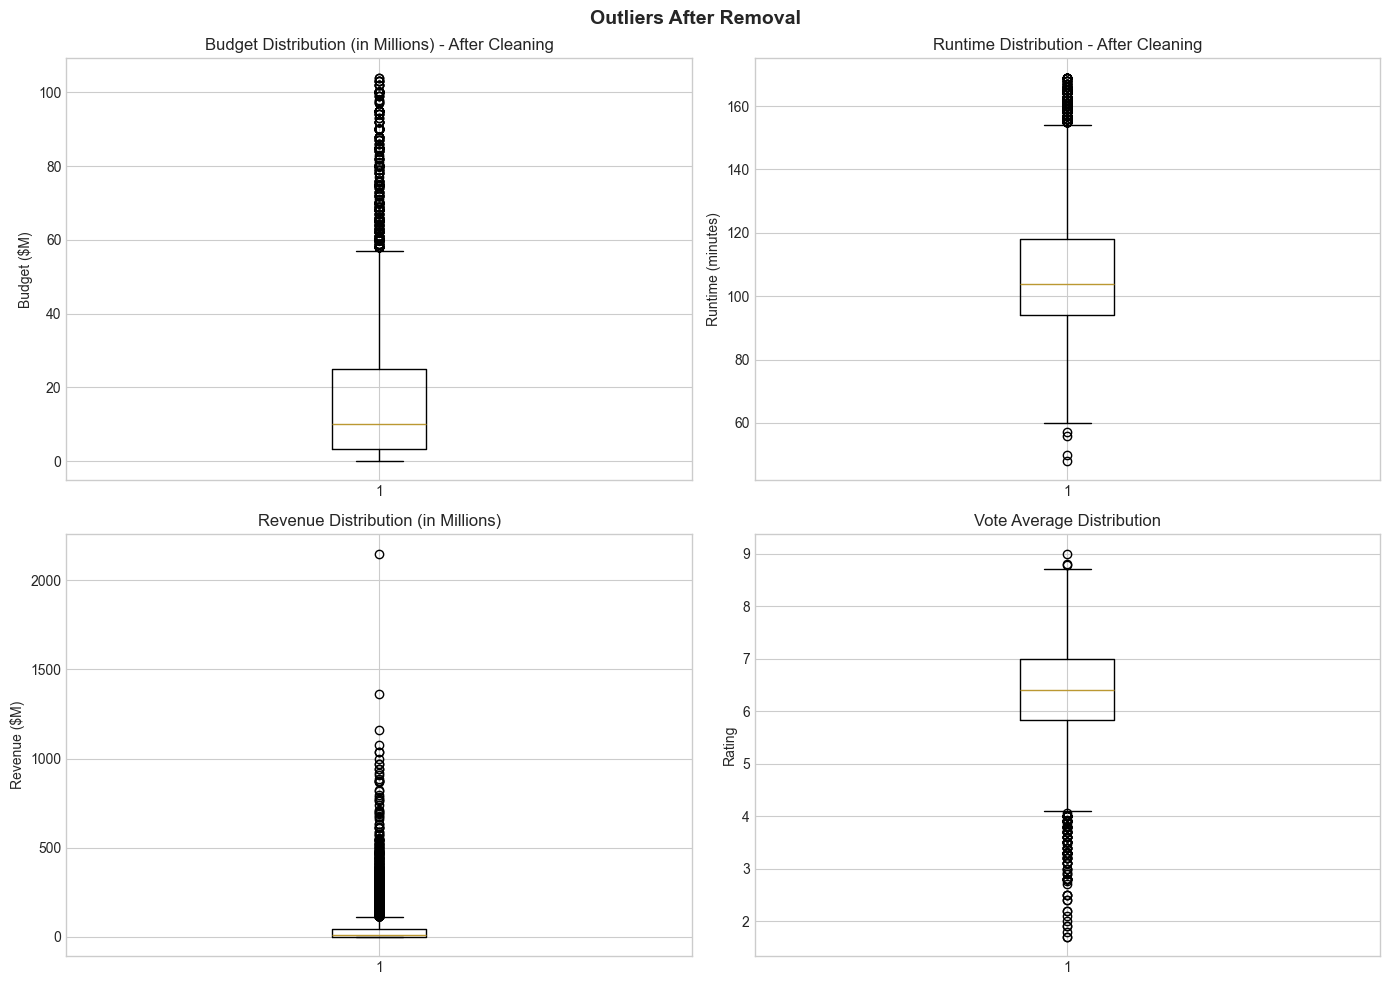

In [267]:
# Apply IQR method to remove outliers for numeric features
def remove_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Remove outliers for budget, runtime (but keep high revenue - we want to predict success!)
df_success = remove_outliers_iqr(df_success, 'budget', multiplier=3)  # Less aggressive for budget
df_success = remove_outliers_iqr(df_success, 'runtime', multiplier=2)

# Also filter unrealistic values
df_success = df_success[df_success['runtime'] >= 30]  # At least 30 min movie
df_success = df_success[df_success['runtime'] <= 300]  # Max 5 hours

print(f"Rows after outlier removal: {len(df_success):,}")

# Visualize after removal
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].boxplot(df_success['budget'] / 1e6)
axes[0, 0].set_title('Budget Distribution (in Millions) - After Cleaning')
axes[0, 0].set_ylabel('Budget ($M)')

axes[0, 1].boxplot(df_success['runtime'])
axes[0, 1].set_title('Runtime Distribution - After Cleaning')
axes[0, 1].set_ylabel('Runtime (minutes)')

axes[1, 0].boxplot(df_success['revenue'] / 1e6)
axes[1, 0].set_title('Revenue Distribution (in Millions)')
axes[1, 0].set_ylabel('Revenue ($M)')

axes[1, 1].boxplot(df_success['vote_average'])
axes[1, 1].set_title('Vote Average Distribution')
axes[1, 1].set_ylabel('Rating')

plt.suptitle('Outliers After Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [268]:
# FEATURE ENGINEERING FOR SUCCESS PREDICTION

# Define Success (Target Variable) - STRICTER CRITERIA
# Success = ROI > 150% AND vote_average >= 6.5
# This ensures BOTH financial success AND decent quality

df_success['ROI'] = ((df_success['revenue'] - df_success['budget']) / df_success['budget']) * 100

# More balanced criteria: must be profitable AND have decent rating
df_success['is_successful'] = (
    (df_success['ROI'] > 150) &  # At least 2.5x return
    (df_success['vote_average'] >= 6.5)  # At least decent rating
).astype(int)

print(f"Success distribution:")
print(df_success['is_successful'].value_counts())
print(f"\nSuccess rate: {df_success['is_successful'].mean()*100:.1f}%")

# Check if classes are balanced enough
success_rate = df_success['is_successful'].mean()
if success_rate > 0.7:
    print("\n Too many successful movies! Making criteria stricter...")
    # Even stricter: top performers only
    df_success['is_successful'] = (
        (df_success['ROI'] > 200) &  # At least 3x return
        (df_success['vote_average'] >= 7.0)  # Good rating
    ).astype(int)
    print(f"New Success rate: {df_success['is_successful'].mean()*100:.1f}%")
elif success_rate < 0.2:
    print("\n Too few successful movies! Making criteria looser...")
    df_success['is_successful'] = (
        (df_success['ROI'] > 100) &  # At least 2x return
        (df_success['vote_average'] >= 6.0)  # Decent rating
    ).astype(int)
    print(f"New Success rate: {df_success['is_successful'].mean()*100:.1f}%")

print(f"\nFinal distribution:")
print(df_success['is_successful'].value_counts())

Success distribution:
is_successful
0    7931
1    2339
Name: count, dtype: int64

Success rate: 22.8%

Final distribution:
is_successful
0    7931
1    2339
Name: count, dtype: int64


In [269]:
# Extract features from text columns

# Function to count items in comma-separated lists
def count_items(text):
    if pd.isna(text) or text == '':
        return 0
    return len([x.strip() for x in str(text).split(',') if x.strip()])

# Function to get first item (primary)
def get_primary(text):
    if pd.isna(text) or text == '':
        return 'Unknown'
    items = [x.strip() for x in str(text).split(',') if x.strip()]
    return items[0] if items else 'Unknown'

# Extract features
df_success['cast_count'] = df_success['cast'].apply(count_items)
df_success['primary_genre'] = df_success['genres'].apply(get_primary)
df_success['genre_count'] = df_success['genres'].apply(count_items)
df_success['has_tagline'] = (df_success['tagline'] != '').astype(int)
df_success['overview_length'] = df_success['overview'].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
df_success['has_director'] = (df_success['director'] != '').astype(int)
df_success['has_composer'] = (df_success['music_composer'] != '').astype(int)
df_success['has_writers'] = (df_success['writers'] != '').astype(int)
df_success['has_producers'] = (df_success['producers'] != '').astype(int)
df_success['has_dop'] = (df_success['director_of_photography'] != '').astype(int)

# Extract release month and season
df_success['release_month'] = df_success['release_date'].dt.month.fillna(1).astype(int)
df_success['release_quarter'] = ((df_success['release_month'] - 1) // 3) + 1

# Budget era adjustment (movies from 2010+ have higher budgets)
df_success['is_modern'] = (df_success['release_year'] >= 2010).astype(int)
df_success['budget_log'] = np.log1p(df_success['budget'])

print("Features created:")
print(df_success[['cast_count', 'primary_genre', 'genre_count', 'has_tagline', 
                  'overview_length', 'release_month', 'is_modern', 'budget_log']].head())

Features created:
   cast_count primary_genre  genre_count  has_tagline  overview_length  \
2          28        Comedy            1            1              237   
3          31        Action            3            1              144   
6         103     Adventure            3            1              312   
7          68     Animation            2            1              333   
8         175        Comedy            3            1              238   

   release_month  is_modern  budget_log  
2             12          0   15.201805  
3             10          0   16.860033  
6              5          0   16.213406  
7              5          0   18.358805  
8              6          0   17.822844  


In [270]:
# Create reputation scores for key personnel (INCLUDING ACTORS)

# Calculate historical success rates for directors, composers, actors, etc.
def calculate_reputation_scores(df, column_name, min_movies=2, top_n_per_row=None):
    """
    Calculate average success rate for each person in the column.
    
    Args:
        df: DataFrame with 'is_successful' column
        column_name: Column containing comma-separated names
        min_movies: Minimum number of movies for reputation calculation
        top_n_per_row: Only consider top N names per row (for actors - lead roles)
    """
    reputation = {}
    person_movies = {}
    
    for idx, row in df.iterrows():
        names = str(row[column_name]).split(',')
        if top_n_per_row:
            names = names[:top_n_per_row]  # Only top N (e.g., lead actors)
        
        for name in names:
            name = name.strip()
            if name and name != '':
                if name not in person_movies:
                    person_movies[name] = []
                person_movies[name].append(row['is_successful'])
    
    for name, successes in person_movies.items():
        if len(successes) >= min_movies:
            reputation[name] = np.mean(successes)
        else:
            reputation[name] = 0.5  # Default for newcomers
    
    return reputation

# Calculate reputation for key personnel
print("Calculating reputation scores...")

# Directors (need at least 2 movies)
director_rep = calculate_reputation_scores(df_success, 'director', min_movies=2)
print(f"  Directors with reputation: {len([k for k, v in director_rep.items() if v != 0.5]):,}")

# Composers (need at least 2 movies)
composer_rep = calculate_reputation_scores(df_success, 'music_composer', min_movies=2)
print(f"  Composers with reputation: {len([k for k, v in composer_rep.items() if v != 0.5]):,}")

# Writers (need at least 2 movies)
writer_rep = calculate_reputation_scores(df_success, 'writers', min_movies=2)
print(f"  Writers with reputation: {len([k for k, v in writer_rep.items() if v != 0.5]):,}")

# Producers (need at least 2 movies)
producer_rep = calculate_reputation_scores(df_success, 'producers', min_movies=2)
print(f"  Producers with reputation: {len([k for k, v in producer_rep.items() if v != 0.5]):,}")

# ACTORS - NEW! (need at least 3 movies, only top 5 billed actors per movie)
actor_rep = calculate_reputation_scores(df_success, 'cast', min_movies=3, top_n_per_row=5)
print(f"  Actors with reputation: {len([k for k, v in actor_rep.items() if v != 0.5]):,}")

# Apply reputation scores
def get_reputation_score(text, reputation_dict, top_n=3):
    """Get average reputation score for names in text"""
    if pd.isna(text) or text == '':
        return 0.5
    names = [x.strip() for x in str(text).split(',') if x.strip()]
    if not names:
        return 0.5
    scores = [reputation_dict.get(name, 0.5) for name in names[:top_n]]
    return np.mean(scores)

df_success['director_reputation'] = df_success['director'].apply(lambda x: get_reputation_score(x, director_rep))
df_success['composer_reputation'] = df_success['music_composer'].apply(lambda x: get_reputation_score(x, composer_rep))
df_success['writer_reputation'] = df_success['writers'].apply(lambda x: get_reputation_score(x, writer_rep))
df_success['producer_reputation'] = df_success['producers'].apply(lambda x: get_reputation_score(x, producer_rep))

# NEW: Actor reputation (average of top 5 billed actors)
df_success['actor_reputation'] = df_success['cast'].apply(lambda x: get_reputation_score(x, actor_rep, top_n=5))

print("\nReputation scores calculated!")
print(df_success[['director_reputation', 'composer_reputation', 'writer_reputation', 
                  'producer_reputation', 'actor_reputation']].describe())

Calculating reputation scores...
  Directors with reputation: 1,729
  Directors with reputation: 1,729
  Composers with reputation: 1,024
  Composers with reputation: 1,024
  Writers with reputation: 3,625
  Writers with reputation: 3,625
  Producers with reputation: 6,038
  Producers with reputation: 6,038
  Actors with reputation: 2,287
  Actors with reputation: 2,287

Reputation scores calculated!
       director_reputation  composer_reputation  writer_reputation  \
count         10270.000000         10270.000000       10270.000000   
mean              0.321101             0.319258           0.344166   
std               0.231813             0.190727           0.197309   
min               0.000000             0.000000           0.000000   
25%               0.100000             0.176471           0.208333   
50%               0.333333             0.312500           0.361111   
75%               0.500000             0.500000           0.500000   
max               1.000000          

In [271]:
# Encode categorical features

# Encode primary genre
genre_encoder = LabelEncoder()
df_success['genre_encoded'] = genre_encoder.fit_transform(df_success['primary_genre'])

# Save genre encoder for Streamlit
genre_classes = list(genre_encoder.classes_)
print(f"Genres: {genre_classes}")

# Prepare final feature set (NOW INCLUDES ACTOR REPUTATION!)
feature_columns = [
    'budget_log',           # Budget (log-transformed)
    'runtime',              # Runtime in minutes
    'release_year',         # Year of release
    'release_month',        # Month of release
    'release_quarter',      # Quarter of release
    'is_modern',            # Is it a modern movie (2010+)
    'genre_encoded',        # Primary genre
    'genre_count',          # Number of genres
    'cast_count',           # Cast size
    'has_tagline',          # Has marketing tagline
    'overview_length',      # Story description length
    'has_director',         # Has director info
    'has_composer',         # Has composer info
    'has_writers',          # Has writers info
    'has_producers',        # Has producers info
    'has_dop',              # Has cinematographer info
    'director_reputation',  # Director's track record
    'composer_reputation',  # Composer's track record
    'writer_reputation',    # Writer's track record
    'producer_reputation',  # Producer's track record
    'actor_reputation'      # NEW: Actor's track record (avg of top 5 billed)
]

X = df_success[feature_columns].copy()
y = df_success['is_successful'].copy()

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {len(feature_columns)} (including actor_reputation)")
print(f"Target distribution: {y.value_counts().to_dict()}")

Genres: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'Unknown', 'War', 'Western']

Feature matrix shape: (10270, 21)
Features: 21 (including actor_reputation)
Target distribution: {0: 7931, 1: 2339}


In [272]:
# BUILD SUCCESS PREDICTION MODEL

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")

Training set: 8,216 samples
Test set: 2,054 samples


In [273]:
# Train Gradient Boosting Classifier with Hyperparameter Tuning

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

# Initialize model
gb_model = GradientBoostingClassifier(random_state=42)

# Randomized search
print(" Hyperparameter tuning with RandomizedSearchCV...")
random_search = RandomizedSearchCV(
    gb_model, param_grid, n_iter=30, cv=5, 
    scoring='f1', random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_scaled, y_train)

print(f"\n Best parameters: {random_search.best_params_}")
print(f" Best CV F1 Score: {random_search.best_score_:.4f}")

# Get best model
best_model = random_search.best_estimator_

 Hyperparameter tuning with RandomizedSearchCV...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

 Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}
 Best CV F1 Score: 0.7476

 Best parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 3, 'learning_rate': 0.1}
 Best CV F1 Score: 0.7476


In [274]:
# 3.2 Evaluate the model
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(" MODEL EVALUATION RESULTS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Confusion Matrix
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Successful', 'Successful']))

 MODEL EVALUATION RESULTS
Accuracy:  0.9051
Precision: 0.8138
Recall:    0.7564
F1 Score:  0.7841
ROC-AUC:   0.9614

 Classification Report:
                precision    recall  f1-score   support

Not Successful       0.93      0.95      0.94      1586
    Successful       0.81      0.76      0.78       468

      accuracy                           0.91      2054
     macro avg       0.87      0.85      0.86      2054
  weighted avg       0.90      0.91      0.90      2054



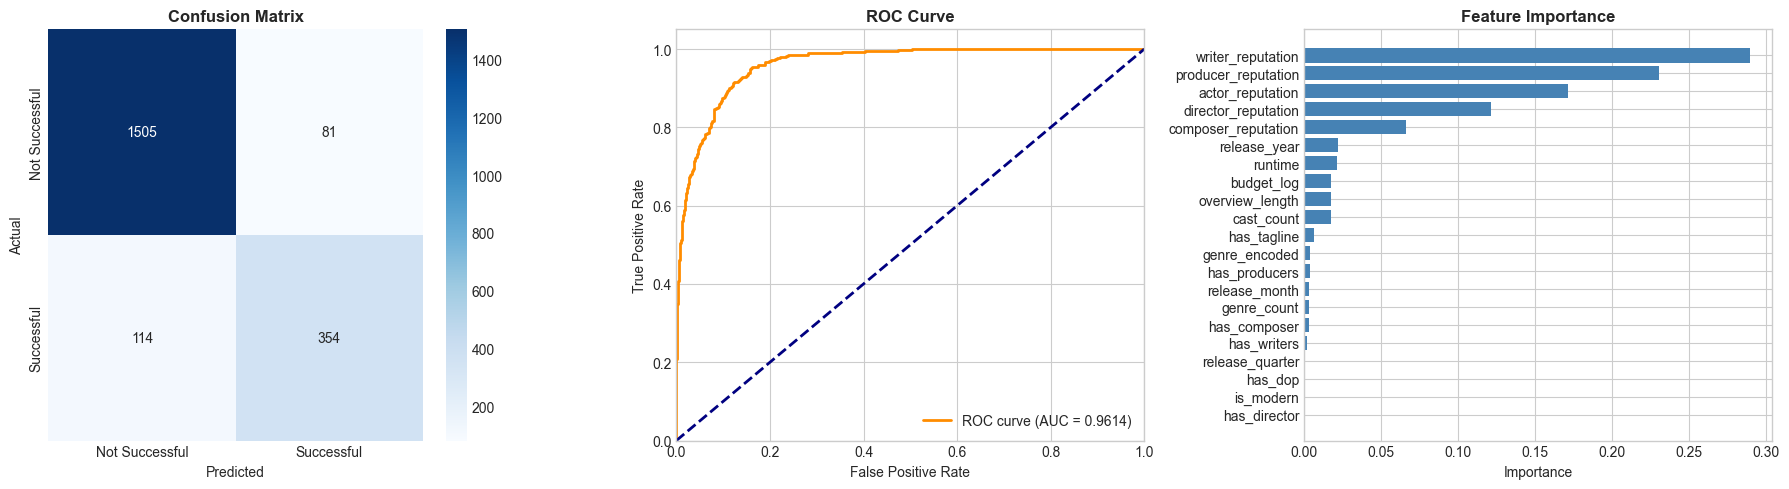

In [275]:
# Visualize Results

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Successful', 'Successful'],
            yticklabels=['Not Successful', 'Successful'])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')

# Feature Importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=True)

axes[2].barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
axes[2].set_xlabel('Importance')
axes[2].set_title('Feature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

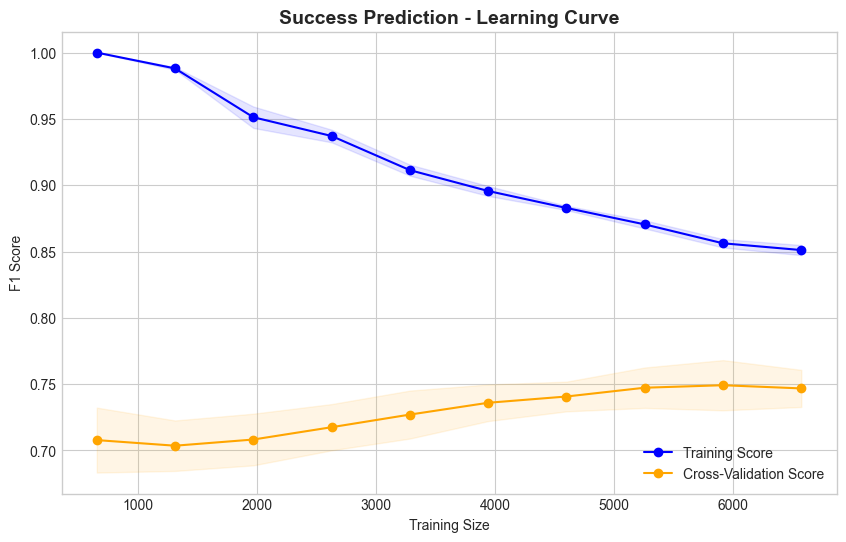

Model shows signs of OVERFITTING (high training score, lower validation score)


In [276]:
# Learning Curves to check Overfitting/Underfitting

def plot_learning_curve(estimator, X, y, title="Learning Curve"):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='f1'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='Cross-Validation Score')
    plt.xlabel('Training Size')
    plt.ylabel('F1 Score')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()
    
    # Analyze overfitting/underfitting
    gap = train_mean[-1] - test_mean[-1]
    if gap > 0.1:
        print("Model shows signs of OVERFITTING (high training score, lower validation score)")
    elif test_mean[-1] < 0.6:
        print("Model shows signs of UNDERFITTING (low scores overall)")
    else:
        print("Model is well-balanced (good generalization)")

plot_learning_curve(best_model, X_train_scaled, y_train, "Success Prediction - Learning Curve")

In [277]:
# SAVE MODEL AND METADATA FOR STREAMLIT

import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/success_prediction_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('models/success_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Get top personnel names for autocomplete (sorted by reputation)
top_directors = sorted(director_rep.keys(), key=lambda x: director_rep[x], reverse=True)[:500]
top_composers = sorted(composer_rep.keys(), key=lambda x: composer_rep[x], reverse=True)[:300]
top_writers = sorted(writer_rep.keys(), key=lambda x: writer_rep[x], reverse=True)[:500]
top_producers = sorted(producer_rep.keys(), key=lambda x: producer_rep[x], reverse=True)[:500]
top_actors = sorted(actor_rep.keys(), key=lambda x: actor_rep[x], reverse=True)[:500]  # NEW!

# Save feature columns and genre encoder (NOW INCLUDES ACTOR DATA!)
model_metadata = {
    'feature_columns': feature_columns,
    'genre_classes': genre_classes,
    # Reputation dictionaries
    'director_reputation': director_rep,
    'composer_reputation': composer_rep,
    'writer_reputation': writer_rep,
    'producer_reputation': producer_rep,
    'actor_reputation': actor_rep,  # NEW: Actor reputation scores
    # Top personnel lists for autocomplete
    'top_directors': top_directors,
    'top_composers': top_composers,
    'top_writers': top_writers,
    'top_producers': top_producers,
    'top_actors': top_actors,  # NEW: Top actors list
    # Model info
    'feature_importances': dict(zip(feature_columns, best_model.feature_importances_)),
    'model_metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }
}

with open('models/success_model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✅ Model and metadata saved successfully!")
print(f"   - models/success_prediction_model.pkl")
print(f"   - models/success_scaler.pkl")
print(f"   - models/success_model_metadata.pkl")
print(f"\n📊 Metadata includes:")
print(f"   - Director reputation: {len(director_rep):,} directors")
print(f"   - Composer reputation: {len(composer_rep):,} composers")
print(f"   - Writer reputation: {len(writer_rep):,} writers")
print(f"   - Producer reputation: {len(producer_rep):,} producers")
print(f"   - Actor reputation: {len(actor_rep):,} actors")  # NEW!

✅ Model and metadata saved successfully!
   - models/success_prediction_model.pkl
   - models/success_scaler.pkl
   - models/success_model_metadata.pkl

📊 Metadata includes:
   - Director reputation: 5,059 directors
   - Composer reputation: 3,136 composers
   - Writer reputation: 13,813 writers
   - Producer reputation: 17,803 producers
   - Actor reputation: 39,794 actors
